In [2]:
from matplotlib import pyplot as plt
import numpy as np
import os
import glob
from scipy.interpolate import PchipInterpolator,interp1d
from scipy.integrate import quad
from scipy.stats import linregress
import kuibit.simdir as SD
import re
import h5py as h5


In [3]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

In [4]:
rmft_colors = ["Red","Blue","Black","Purple"]

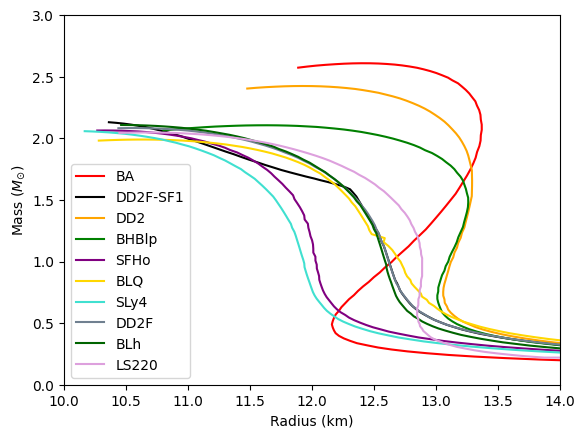

In [5]:
for eos in eos_colors:
    mvr_data = np.loadtxt(f'./Figure_Data/EOS/MVR/CORE/{eos}_MVR.txt')
    plt.plot(mvr_data[:,1],mvr_data[:,0],color=eos_colors[eos],label=eos)
plt.legend()
plt.gca().set_xlim([10,14])
plt.gca().set_ylim([0,3.0])
plt.gca().set_xlabel(r'Radius (km)')
plt.gca().set_ylabel(r'Mass ($M_{\odot}$)')

plt.savefig('./Figures/Final_Paper_Figs/CORE_MVR.pdf',format = 'pdf',dpi = 300)
    

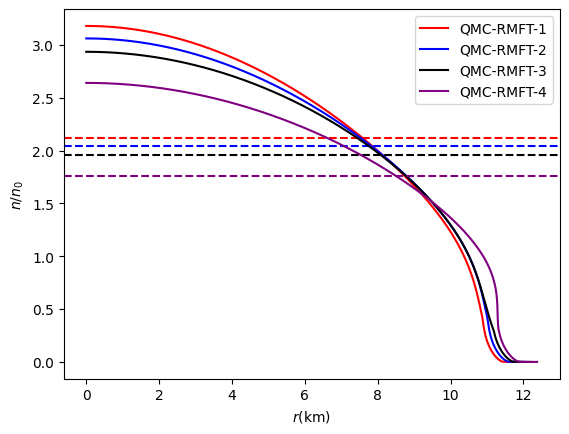

In [6]:
rmft_dens_data = [None,None,None,None]
rmft_stop = [0,0,0,0]


for i in range(4):
    rmft_dens_data[i] = np.loadtxt(f'./Figure_Data/CORE/RMFT_Density_Profile/RMFT{i+1}_density.txt')
    rmft_stop[i] = (float(rmft_dens_data[i][0,1])/0.16)*(2.0/3.0)
    plt.plot(rmft_dens_data[i][:,0],rmft_dens_data[i][:,1]/0.16,color = rmft_colors[i],label=f'QMC-RMFT-{i+1}')
    plt.axhline(y = rmft_stop[i],color=rmft_colors[i],linestyle='--')
plt.gca().set_ylabel(r"$n/n_0$")
plt.gca().set_xlabel(r"$r (\text{km})$")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/RMFT_nb_vs_r.pdf',format = 'pdf',dpi = 300)


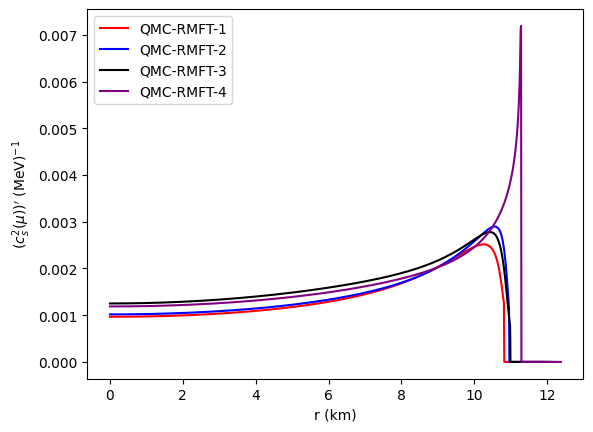

In [7]:
for i in range(4):
    prof_rmft = np.loadtxt(f"./Figure_Data/CORE/RMFT_Alpha_Profile/RMFT_{i+1}_alpha.txt")
    plt.plot(prof_rmft[:,0],prof_rmft[:,1],label=f'QMC-RMFT-{i+1}',color=rmft_colors[i])
plt.gca().set_xlabel('r (km)')
plt.gca().set_ylabel(r"$(c_s^2 (\mu))' \text{ (MeV)}^{-1}$")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/RMFT_cs2prime_vs_r.pdf',format='pdf',dpi = 300)


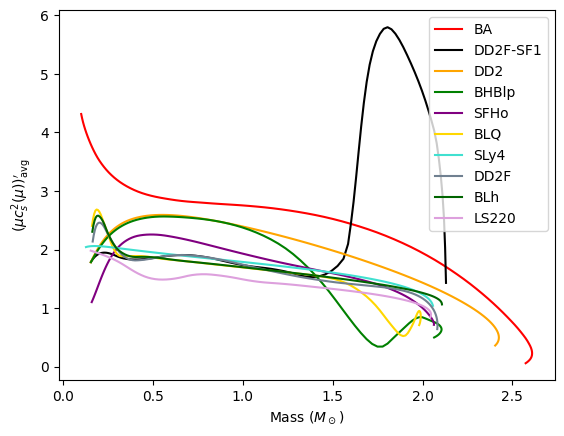

In [8]:
for eos in eos_colors.keys():
    mu_cs2prime = np.loadtxt(f'./Figure_Data/CORE/{eos}_mu_cs2prime.txt')
    plt.plot(mu_cs2prime[:,0],mu_cs2prime[:,1],label=eos,color=eos_colors[eos])

plt.gca().set_xlabel(r'Mass ($M_\odot$)')
plt.gca().set_ylabel(r"$(\mu c_s^2(\mu))_{\text{avg}}'$")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/CORE_mu_cs2prime.pdf',format='pdf',dpi = 300)

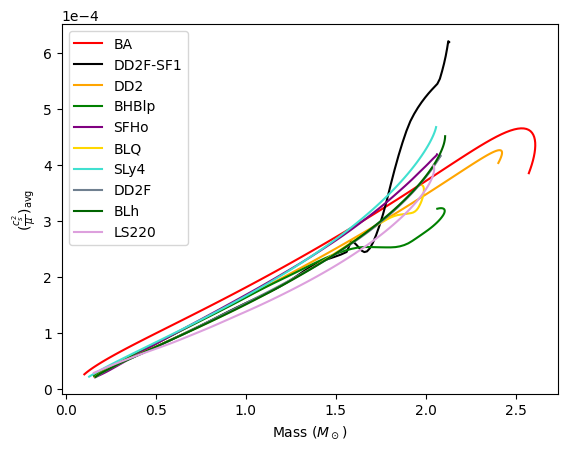

In [9]:

for eos in eos_colors.keys():
    cs2_mu = np.loadtxt(f'./Figure_Data/CORE/{eos}_cs2_mu.txt')
    
    plt.plot(cs2_mu[:,0],cs2_mu[:,1],label=eos,color=eos_colors[eos])
plt.gca().ticklabel_format(axis='y',style='sci',scilimits=(-3,-2))


plt.gca().set_xlabel(r'Mass ($M_\odot$)')
plt.gca().set_ylabel(r"$(\frac{c_s^2}{\mu})_{\text{avg}}$")
plt.legend()

plt.savefig('./Figures/Final_Paper_Figs/CORE_cs2_over_mu.pdf',format='pdf',dpi=300)

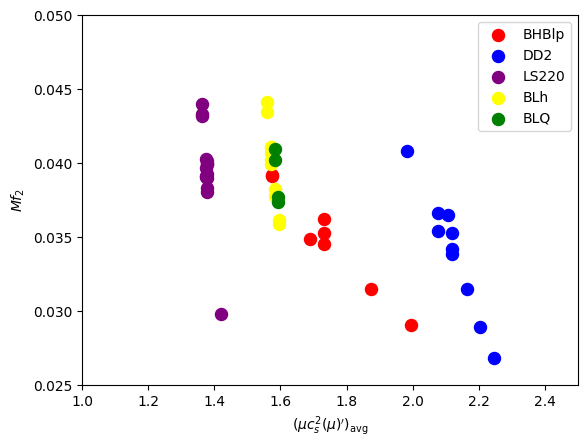

In [25]:
eos_Core_qur = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_Core_qur_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_Core_qur):
    mu_cs2prime_data = np.loadtxt(f'./Figure_Data/CORE/MF2_mu_cs2prime/{eos}_mu_cs2p_CORE.txt')
    plt.scatter(mu_cs2prime_data[:,0],mu_cs2prime_data[:,1],color = eos_Core_qur_colors[i],label=eos,s=75)


plt.ylabel(r'$Mf_2$')
plt.xlabel(r"$(\mu c_s^2(\mu)')_{\text{avg}}$")
plt.ylim([0.025,0.05])
plt.xlim([1.0,2.5])
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.show()

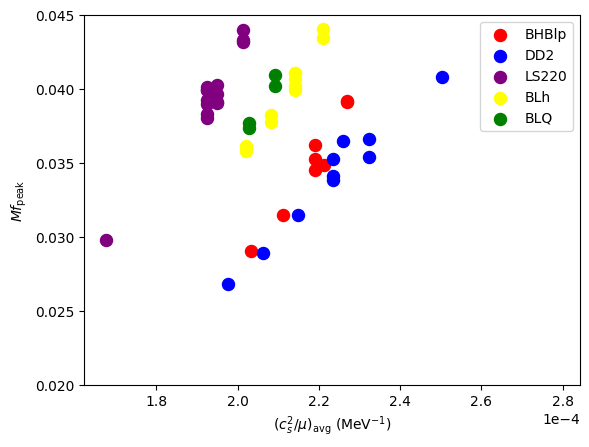

In [24]:
eos_Core_qur = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_Core_qur_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_Core_qur):
    cs2_mu_data = np.loadtxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu.txt')
    plt.scatter(cs2_mu_data[:,0],cs2_mu_data[:,1],color = eos_Core_qur_colors[i],label=eos,s=75)


plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])

plt.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2_mu_CORE.pdf',format='pdf',dpi = 300)

plt.show()

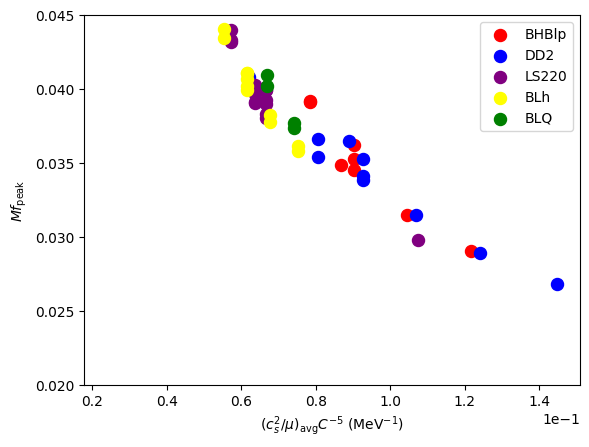

In [23]:
eos_Core_qur = ["BHBlp","DD2","LS220","BLh","BLQ"]
eos_Core_qur_colors = ["red","blue","purple","yellow","green"]

for i,eos in enumerate(eos_Core_qur):
    cs2_mu_data = np.loadtxt(f'./Figure_Data/CORE/Mf2_cs2_mu/{eos}_cs2_mu_Cm5.txt')
    plt.scatter(cs2_mu_data[:,0],cs2_mu_data[:,1],color = eos_Core_qur_colors[i],label=eos,s=75)


plt.ylabel(r'$Mf_{\text{peak}}$')
plt.xlabel(r'$(c_{s}^2/\mu)_{\text{avg}} C^{-5} \text{ (MeV}^{-1})$')
plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
plt.legend()
plt.ylim([0.020,0.045])

plt.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2_mu_Cm5_CORE.pdf',format='pdf',dpi = 300)

plt.show()